In [1]:
# --------------------------------------------------
# Project Root
# --------------------------------------------------

from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import gc
import copy
import time
import random

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

from tqdm import tqdm

from src.utils.config_loader import (
    load_yaml
)

from src.dataset.feature_loader import (
    build_dataloader
)

from src.models.factorized.factorized_vae import (
    FactorizedVAE
)

from src.losses.total_loss import (
    TotalLoss
)

from src.trainers.memory_monitor import (
    MemoryMonitor
)

In [3]:
# --------------------------------------------------
# Seed
# --------------------------------------------------

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)

print("Seed =", SEED)

Seed = 42


In [4]:
# --------------------------------------------------
# Memory Helper
# --------------------------------------------------

monitor = MemoryMonitor()

def print_ram():

    print(
        f"RAM Usage: {monitor.get_ram_gb():.2f} GB"
    )

print_ram()

RAM Usage: 0.28 GB


In [5]:
# --------------------------------------------------
# Configs
# --------------------------------------------------

model_cfg = load_yaml(
    PROJECT_ROOT
    /
    "configs"
    /
    "model_config.yaml"
)

train_cfg = load_yaml(
    PROJECT_ROOT
    /
    "configs"
    /
    "train_config.yaml"
)

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"
)

print(device)

cpu


In [6]:
# --------------------------------------------------
# Merge Configs For Loss
# --------------------------------------------------

merged_cfg = copy.deepcopy(
    model_cfg
)

if "staged_activation" in train_cfg:

    merged_cfg[
        "staged_activation"
    ] = train_cfg[
        "staged_activation"
    ]

print(
    "staged_activation" in merged_cfg
)

True


### **Data Loader**

In [7]:
# --------------------------------------------------
# Loader
# --------------------------------------------------

loader = build_dataloader(

    PROJECT_ROOT,

    split="train"
)

batch = next(
    iter(loader)
)

for k,v in batch.items():

    if torch.is_tensor(v):

        print(
            k,
            tuple(v.shape)
        )

logmel (1, 80, 65)
mr_mag_256 (1, 129, 129)
mr_mag_512 (1, 257, 65)
mr_mag_1024 (1, 513, 33)
magnitude (1, 513, 65)
if (1, 513, 65)
modgd (1, 513, 65)
phase_sin (1, 513, 65)
phase_cos (1, 513, 65)
lengths (1,)


In [8]:
# --------------------------------------------------
# Move Batch
# --------------------------------------------------

batch_gpu = {}

for k,v in batch.items():

    if torch.is_tensor(v):

        batch_gpu[k] = v.to(
            device
        )

    else:

        batch_gpu[k] = v

print("Batch Loaded")

print_ram()

Batch Loaded
RAM Usage: 0.29 GB


In [9]:
# --------------------------------------------------
# Model + Loss
# --------------------------------------------------

model = FactorizedVAE(
    model_cfg
).to(device)

loss_fn = TotalLoss(
    merged_cfg
)

print(

    "Parameters:",

    sum(

        p.numel()

        for p in model.parameters()
    )
)

print_ram()

Parameters: 73217893
RAM Usage: 0.58 GB


In [10]:
# --------------------------------------------------
# Force All Losses Active
# --------------------------------------------------

loss_fn.current_epoch = (
    train_cfg[
        "training"
    ][
        "epochs"
    ]
)

loss_fn.total_epochs = (
    train_cfg[
        "training"
    ][
        "epochs"
    ]
)

print(

    loss_fn.activation_flags()
)

{'phase': True, 'kl': True, 'orthogonality': True, 'tc': True}


In [11]:
# --------------------------------------------------
# Forward Pass
# --------------------------------------------------

model.eval()

with torch.no_grad():

    outputs = model(
        batch_gpu
    )

print()

print(
    outputs.keys()
)

print()

for k,v in outputs[
    "reconstructions"
].items():

    print(
        k,
        tuple(v.shape)
    )

print()

print_ram()


dict_keys(['groups', 'latents', 'mu', 'logvar', 'reconstructions'])

logmel (1, 80, 65)
mr_mag_256 (1, 129, 129)
mr_mag_512 (1, 257, 65)
magnitude (1, 513, 65)
mr_mag_1024 (1, 513, 33)
if (1, 513, 65)
modgd (1, 513, 65)
phase_sin (1, 513, 65)
phase_cos (1, 513, 65)

RAM Usage: 0.95 GB


In [12]:
# --------------------------------------------------
# Shape Verification
# --------------------------------------------------

shape_rows = []

for feature in outputs[
    "reconstructions"
]:

    shape_rows.append({

        "Feature":
            feature,

        "Prediction":
            tuple(
                outputs[
                    "reconstructions"
                ][
                    feature
                ].shape
            ),

        "Target":
            tuple(
                batch_gpu[
                    feature
                ].shape
            )
    })

pd.DataFrame(
    shape_rows
)

,Feature,Prediction,Target
0,logmel,"(1, 80, 65)","(1, 80, 65)"
1,mr_mag_256,"(1, 129, 129)","(1, 129, 129)"
2,mr_mag_512,"(1, 257, 65)","(1, 257, 65)"
3,magnitude,"(1, 513, 65)","(1, 513, 65)"
4,mr_mag_1024,"(1, 513, 33)","(1, 513, 33)"
5,if,"(1, 513, 65)","(1, 513, 65)"
6,modgd,"(1, 513, 65)","(1, 513, 65)"
7,phase_sin,"(1, 513, 65)","(1, 513, 65)"
8,phase_cos,"(1, 513, 65)","(1, 513, 65)"


In [13]:
# --------------------------------------------------
# Initial Loss Breakdown
# --------------------------------------------------

loss_dict = loss_fn(

    outputs,

    batch_gpu
)

loss_rows = []

for k,v in loss_dict.items():

    loss_rows.append({

        "Metric": k,

        "Value":
            float(
                v.detach()
            )
    })

loss_df = pd.DataFrame(
    loss_rows
)

loss_df

,Metric,Value
0,reconstruction,7.184325
1,logmel_loss,0.234088
2,logmel_l1,0.204970
3,logmel_mse,0.058235
4,mr_mag_256_loss,0.277808
5,mr_mag_256_l1,0.238130
6,mr_mag_256_mse,0.079355
7,mr_mag_512_loss,0.307127
8,mr_mag_512_l1,0.261364
9,mr_mag_512_mse,0.091527


In [14]:
# --------------------------------------------------
# Initial Summary
# --------------------------------------------------

print()

print(
    "Initial Total Loss:",
    float(
        loss_dict[
            "total"
        ].detach()
    )
)

print()

print(
    "Reconstruction:",
    float(
        loss_dict[
            "reconstruction"
        ].detach()
    )
)

print()

print(
    "Multires:",
    float(
        loss_dict[
            "multires"
        ].detach()
    )
)

print()

print(
    "Orthogonality:",
    float(
        loss_dict[
            "orthogonality"
        ].detach()
    )
)

print()

print(
    "TC:",
    float(
        loss_dict[
            "tc"
        ].detach()
    )
)


Initial Total Loss: 10.344022750854492

Reconstruction: 7.184325218200684

Multires: 1.0438134670257568

Orthogonality: 0.014059167355298996

TC: 0.0


In [15]:
# --------------------------------------------------
# Timing Benchmark
# --------------------------------------------------

model.train()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

start = time.time()

optimizer.zero_grad(
    set_to_none=True
)

outputs = model(
    batch_gpu
)

loss = loss_fn(

    outputs,

    batch_gpu
)[
    "total"
]

loss.backward()

optimizer.step()

elapsed = (
    time.time()
    -
    start
)

print()

print(
    "Step Time:",
    round(
        elapsed,
        3
    ),
    "sec"
)

print()

print(
    "Estimated 100 Epochs:",
    round(
        elapsed * 100 / 60,
        2
    ),
    "minutes"
)

del outputs
del loss

gc.collect()


Step Time: 6.22 sec

Estimated 100 Epochs: 10.37 minutes


15

In [16]:
# --------------------------------------------------
# Latent Statistics
# --------------------------------------------------

model.eval()

with torch.no_grad():

    outputs = model(
        batch_gpu
    )

latent_rows = []

for name,z in outputs[
    "latents"
].items():

    latent_rows.append({

        "Factor":
            name,

        "Mean":
            float(
                z.mean()
            ),

        "Std":
            float(
                z.std()
            ),

        "AbsMax":
            float(
                z.abs().max()
            )
    })

latent_df = pd.DataFrame(
    latent_rows
)

latent_df

,Factor,Mean,Std,AbsMax
0,content,-0.007843,1.090903,3.059470
1,speaker,-0.054448,1.053292,3.986445
2,environment,0.077514,1.179359,2.714724
3,excitation,0.221800,0.838141,1.634431
4,fidelity,0.141600,1.215820,3.010058


In [17]:
# --------------------------------------------------
# Initial KL Values
# --------------------------------------------------

kl_rows = []

for name in outputs[
    "mu"
]:

    mu = outputs[
        "mu"
    ][
        name
    ]

    logvar = outputs[
        "logvar"
    ][
        name
    ]

    kl = (

        -0.5

        *

        torch.mean(

            1

            +

            logvar

            -

            mu.pow(2)

            -

            logvar.exp()
        )
    )

    kl_rows.append({

        "Factor":
            name,

        "KL":
            float(
                kl.detach()
            )
    })

pd.DataFrame(
    kl_rows
)

,Factor,KL
0,content,0.133800
1,speaker,0.108199
2,environment,0.108271
3,excitation,0.125688
4,fidelity,0.108204


In [18]:
# --------------------------------------------------
# Latent Similarity Matrix
# --------------------------------------------------

names = list(
    outputs[
        "latents"
    ].keys()
)

matrix = np.zeros(

    (
        len(names),
        len(names)
    )
)

for i in range(len(names)):

    for j in range(len(names)):

        z1 = outputs[
            "latents"
        ][
            names[i]
        ]

        z2 = outputs[
            "latents"
        ][
            names[j]
        ]

        common = min(

            z1.shape[-1],

            z2.shape[-1]
        )

        z1n = F.normalize(

            z1[
                :,
                :common
            ],

            dim=-1
        )

        z2n = F.normalize(

            z2[
                :,
                :common
            ],

            dim=-1
        )

        sim = (

            z1n
            *
            z2n

        ).sum(
            dim=-1
        ).mean()

        matrix[
            i,
            j
        ] = float(
            sim.detach()
        )

pd.DataFrame(

    matrix,

    index=names,

    columns=names
)

,content,speaker,environment,excitation,fidelity
content,1.000000,0.060526,0.154138,-0.048760,0.001612
speaker,0.060526,1.000000,-0.141178,0.174902,-0.103105
environment,0.154138,-0.141178,1.000000,0.057681,-0.076772
excitation,-0.048760,0.174902,0.057681,1.000000,0.246347
fidelity,0.001612,-0.103105,-0.076772,0.246347,1.000000


In [19]:
# --------------------------------------------------
# Tracking Containers
# --------------------------------------------------

history_total = []

history_recon = []

history_multires = []

history_ortho = []

history_content_kl = []

history_speaker_kl = []

history_environment_kl = []

history_excitation_kl = []

history_fidelity_kl = []

history_grad = []

print(
    "Tracking Ready"
)

Tracking Ready


In [20]:
# --------------------------------------------------
# Overfit Setup
# --------------------------------------------------

epochs = 300

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

print()

print(
    "Epochs:",
    epochs
)

print()

print(
    "LR:",
    1e-4
)

print()

print(
    "Weight Decay:",
    1e-4
)


Epochs: 300

LR: 0.0001

Weight Decay: 0.0001


In [21]:
# --------------------------------------------------
# Single Sample Overfit
# --------------------------------------------------

from tqdm import tqdm

model.train()

for epoch in tqdm(

    range(epochs),

    desc="Overfit"
):

    optimizer.zero_grad(
        set_to_none=True
    )

    outputs = model(
        batch_gpu
    )

    loss_dict = loss_fn(

        outputs,

        batch_gpu
    )

    loss = loss_dict[
        "total"
    ]

    loss.backward()

    grad_norm = 0.0

    for p in model.parameters():

        if p.grad is not None:

            grad_norm += (
                p.grad.norm()
                .item()
            )

    optimizer.step()

    history_total.append(

        float(
            loss.detach()
        )
    )

    history_recon.append(

        float(
            loss_dict[
                "reconstruction"
            ].detach()
        )
    )

    history_multires.append(

        float(
            loss_dict[
                "multires"
            ].detach()
        )
    )

    history_ortho.append(

        float(
            loss_dict[
                "orthogonality"
            ].detach()
        )
    )

    history_content_kl.append(

        float(
            loss_dict[
                "content_kl"
            ].detach()
        )
    )

    history_speaker_kl.append(

        float(
            loss_dict[
                "speaker_kl"
            ].detach()
        )
    )

    history_environment_kl.append(

        float(
            loss_dict[
                "environment_kl"
            ].detach()
        )
    )

    history_excitation_kl.append(

        float(
            loss_dict[
                "excitation_kl"
            ].detach()
        )
    )

    history_fidelity_kl.append(

        float(
            loss_dict[
                "fidelity_kl"
            ].detach()
        )
    )

    history_grad.append(
        grad_norm
    )

    if epoch % 25 == 0:

        print()

        print(
            f"Epoch {epoch}"
        )

        print(
            "Loss:",
            round(
                history_total[-1],
                4
            )
        )

        print(
            "Recon:",
            round(
                history_recon[-1],
                4
            )
        )

        print(
            "Grad:",
            round(
                history_grad[-1],
                4
            )
        )

    del outputs
    del loss_dict
    del loss

    gc.collect()

Overfit:   0%|          | 0/300 [00:00<?, ?it/s]


Epoch 0
Loss: 10.4812
Recon: 7.2164
Grad: 42.4545


Overfit:   9%|▊         | 26/300 [03:12<33:52,  7.42s/it]


Epoch 25
Loss: 9.1778
Recon: 6.5596
Grad: 32.5963


Overfit:  17%|█▋        | 51/300 [05:56<26:04,  6.28s/it]

...

Overfit:  84%|████████▎ | 251/300 [28:25<05:12,  6.37s/it]


Epoch 250
Loss: 6.4432
Recon: 5.0659
Grad: 17.6634


Overfit:  92%|█████████▏| 276/300 [31:09<02:45,  6.91s/it]


Epoch 275
Loss: 6.2949
Recon: 5.0538
Grad: 8.8086


Overfit: 100%|██████████| 300/300 [33:50<00:00,  6.77s/it]


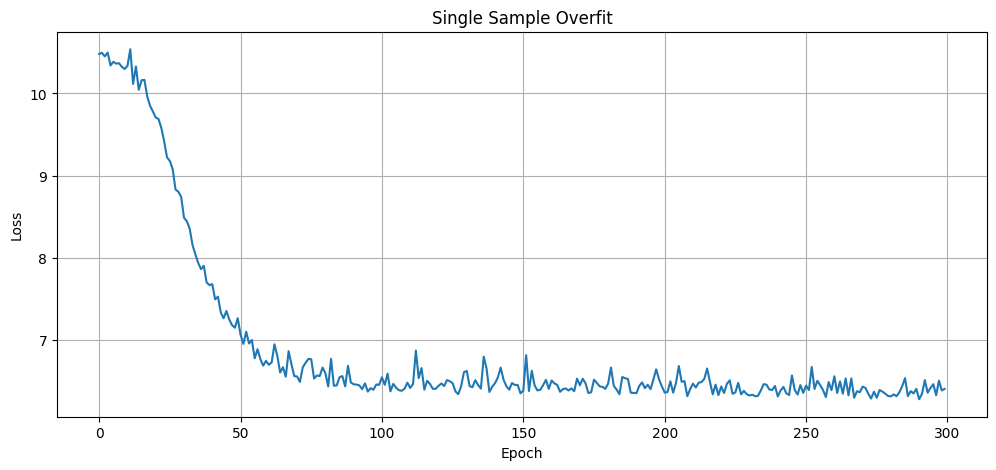


Initial: 10.481160163879395
Final: 6.403841972351074
Reduction: 4.07731819152832
Ratio: 0.6109859855419687


In [22]:
# --------------------------------------------------
# Total Loss Curve
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(
    figsize=(12,5)
)

plt.plot(
    history_total
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Single Sample Overfit"
)

plt.grid()

plt.show()

print()

print(
    "Initial:",
    history_total[0]
)

print(
    "Final:",
    history_total[-1]
)

print(
    "Reduction:",
    history_total[0]
    -
    history_total[-1]
)

print(
    "Ratio:",
    history_total[-1]
    /
    history_total[0]
)

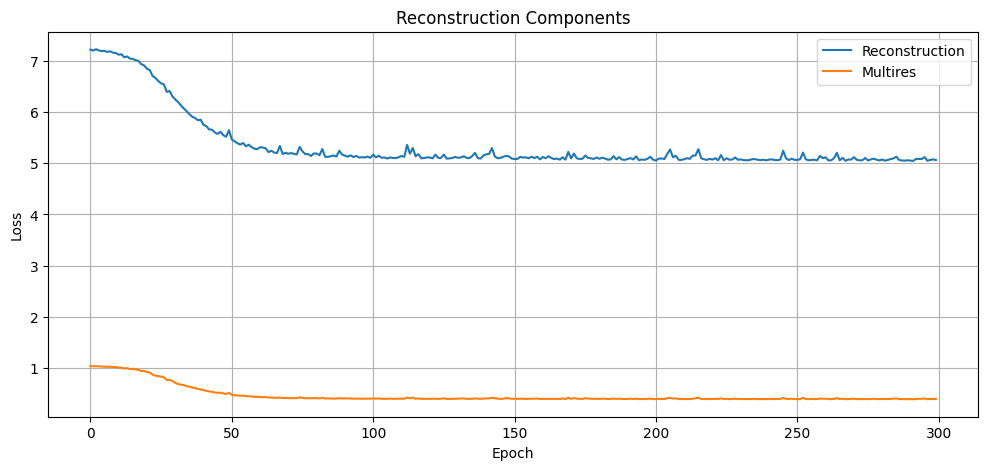

In [23]:
# --------------------------------------------------
# Reconstruction Components
# --------------------------------------------------

plt.figure(
    figsize=(12,5)
)

plt.plot(

    history_recon,

    label="Reconstruction"
)

plt.plot(

    history_multires,

    label="Multires"
)

plt.legend()

plt.grid()

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Reconstruction Components"
)

plt.show()

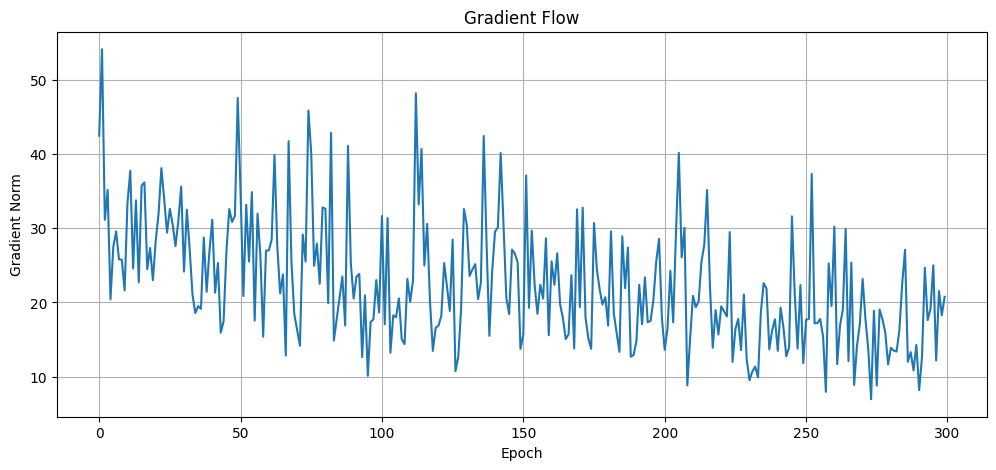


Min: 6.966509862627245
Max: 54.103320603917844
Final: 20.753130100640544


In [24]:
# --------------------------------------------------
# Gradient Trend
# --------------------------------------------------

plt.figure(
    figsize=(12,5)
)

plt.plot(
    history_grad
)

plt.grid()

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Gradient Norm"
)

plt.title(
    "Gradient Flow"
)

plt.show()

print()

print(
    "Min:",
    np.min(
        history_grad
    )
)

print(
    "Max:",
    np.max(
        history_grad
    )
)

print(
    "Final:",
    history_grad[-1]
)

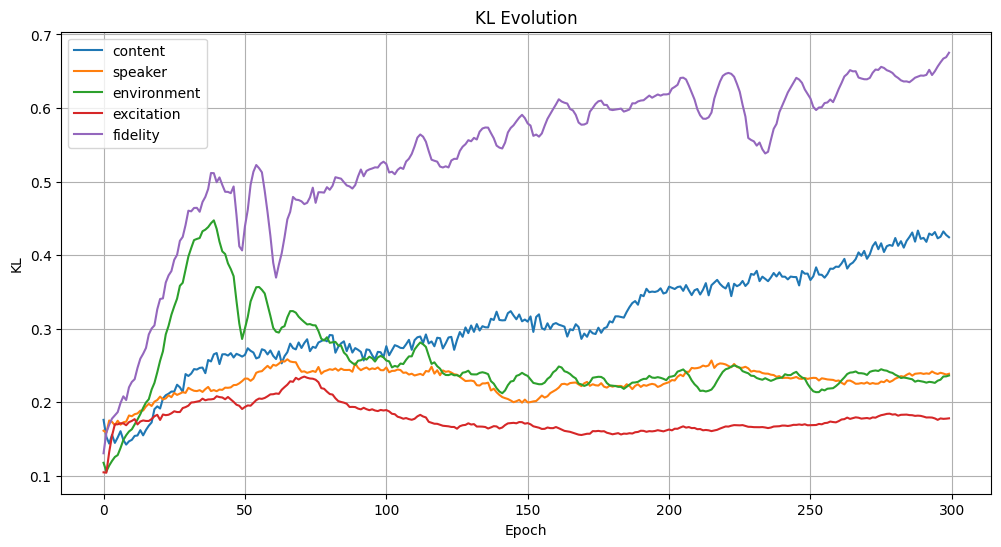

In [25]:
# --------------------------------------------------
# KL Evolution
# --------------------------------------------------

plt.figure(
    figsize=(12,6)
)

plt.plot(
    history_content_kl,
    label="content"
)

plt.plot(
    history_speaker_kl,
    label="speaker"
)

plt.plot(
    history_environment_kl,
    label="environment"
)

plt.plot(
    history_excitation_kl,
    label="excitation"
)

plt.plot(
    history_fidelity_kl,
    label="fidelity"
)

plt.legend()

plt.grid()

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "KL"
)

plt.title(
    "KL Evolution"
)

plt.show()

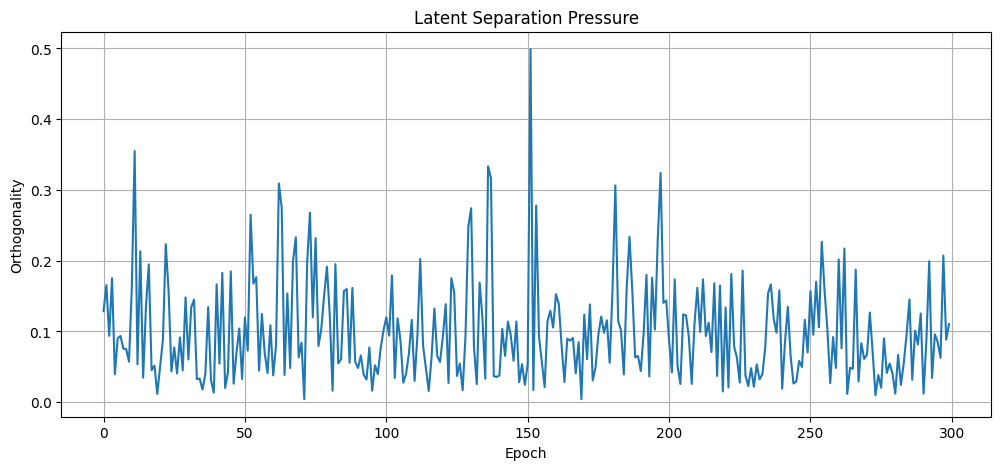


Initial: 0.1286892294883728
Final: 0.11029107868671417


In [26]:
# --------------------------------------------------
# Orthogonality Trend
# --------------------------------------------------

plt.figure(
    figsize=(12,5)
)

plt.plot(
    history_ortho
)

plt.grid()

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Orthogonality"
)

plt.title(
    "Latent Separation Pressure"
)

plt.show()

print()

print(
    "Initial:",
    history_ortho[0]
)

print(
    "Final:",
    history_ortho[-1]
)

In [27]:
# --------------------------------------------------
# Final Forward
# --------------------------------------------------

model.eval()

with torch.no_grad():

    outputs = model(
        batch_gpu
    )

print(
    "Forward OK"
)

Forward OK


In [28]:
# --------------------------------------------------
# Final Latent Statistics
# --------------------------------------------------

rows = []

for name,z in outputs[
    "latents"
].items():

    rows.append({

        "Factor":
            name,

        "Mean":
            float(
                z.mean()
            ),

        "Std":
            float(
                z.std()
            ),

        "AbsMax":
            float(
                z.abs().max()
            )
    })

pd.DataFrame(
    rows
)

,Factor,Mean,Std,AbsMax
0,content,-0.004241,1.152426,3.127346
1,speaker,0.207335,1.142252,2.729275
2,environment,0.029484,1.048662,4.232141
3,excitation,0.073624,0.977632,2.915786
4,fidelity,-0.059661,1.409560,3.012529


In [29]:
# --------------------------------------------------
# Final KL
# --------------------------------------------------

rows = []

for name in outputs[
    "mu"
]:

    mu = outputs[
        "mu"
    ][
        name
    ]

    logvar = outputs[
        "logvar"
    ][
        name
    ]

    kl = (

        -0.5

        *

        torch.mean(

            1

            +

            logvar

            -

            mu.pow(2)

            -

            logvar.exp()
        )
    )

    rows.append({

        "Factor":
            name,

        "KL":
                float(
                    kl
                    .detach()
                )
    })

pd.DataFrame(
    rows
)

,Factor,KL
0,content,0.436899
1,speaker,0.238440
2,environment,0.238027
3,excitation,0.172477
4,fidelity,0.679133


In [30]:
# --------------------------------------------------
# Final Similarity Matrix
# --------------------------------------------------

names = list(
    outputs[
        "latents"
    ].keys()
)

matrix = np.zeros(

    (
        len(names),
        len(names)
    )
)

for i in range(len(names)):

    for j in range(len(names)):

        z1 = outputs[
            "latents"
        ][
            names[i]
        ]

        z2 = outputs[
            "latents"
        ][
            names[j]
        ]

        common = min(

            z1.shape[-1],

            z2.shape[-1]
        )

        z1 = F.normalize(

            z1[
                :,
                :common
            ],

            dim=-1
        )

        z2 = F.normalize(

            z2[
                :,
                :common
            ],

            dim=-1
        )

        sim = (

            z1 * z2

        ).sum(
            dim=-1
        ).mean()

        matrix[
            i,
            j
        ] = float(
            sim.detach()
        )

pd.DataFrame(

    matrix,

    index=names,

    columns=names
)

,content,speaker,environment,excitation,fidelity
content,1.000000,0.142058,-0.037295,-0.252944,0.002708
speaker,0.142058,1.000000,0.002002,0.173084,0.205313
environment,-0.037295,0.002002,1.000000,0.175215,-0.176891
excitation,-0.252944,0.173084,0.175215,1.000000,-0.098600
fidelity,0.002708,0.205313,-0.176891,-0.098600,1.000000


In [31]:
# --------------------------------------------------
# Fidelity Impact
# --------------------------------------------------

target_lengths = {

    "logmel":
        batch_gpu[
            "logmel"
        ].shape[-1],

    "mr_mag_256":
        batch_gpu[
            "mr_mag_256"
        ].shape[-1],

    "mr_mag_512":
        batch_gpu[
            "mr_mag_512"
        ].shape[-1],

    "magnitude":
        batch_gpu[
            "magnitude"
        ].shape[-1],

    "mr_mag_1024":
        batch_gpu[
            "mr_mag_1024"
        ].shape[-1]
}

latents_zero = {

    k:v.clone()

    for k,v in outputs[
        "latents"
    ].items()
}

latents_zero[
    "fidelity"
] = torch.zeros_like(

    latents_zero[
        "fidelity"
    ]
)

recon_no_fidelity = model.decode(

    latents_zero,

    target_lengths
)

rows = []

for feature in [

    "logmel",

    "magnitude",

    "if"
]:

    impact = (

        outputs[
            "reconstructions"
        ][
            feature
        ]

        -

        recon_no_fidelity[
            feature
        ]

    ).abs().mean()

    rows.append({

        "Feature":
            feature,

        "Impact":
            float(
                impact
            )
    })

pd.DataFrame(
    rows
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_14784\2372371070.py:91: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  float(


,Feature,Impact
0,logmel,0.119756
1,magnitude,0.164534
2,if,0.623270


In [32]:
# --------------------------------------------------
# Environment Impact
# --------------------------------------------------

latents_zero = {

    k:v.clone()

    for k,v in outputs[
        "latents"
    ].items()
}

latents_zero[
    "environment"
] = torch.zeros_like(

    latents_zero[
        "environment"
    ]
)

recon_no_env = model.decode(

    latents_zero,

    target_lengths
)

rows = []

for feature in [

    "logmel",

    "magnitude",

    "if"
]:

    impact = (

        outputs[
            "reconstructions"
        ][
            feature
        ]

        -

        recon_no_env[
            feature
        ]

    ).abs().mean()

    rows.append({

        "Feature":
            feature,

        "Impact":
            float(
                impact
            )
    })

pd.DataFrame(
    rows
)

,Feature,Impact
0,logmel,0.045044
1,magnitude,0.054898
2,if,0.280943


In [33]:
# --------------------------------------------------
# Final Summary
# --------------------------------------------------

print()

print(
    "=" * 60
)

print(
    "8B OVERFIT SUMMARY"
)

print(
    "=" * 60
)

print()

print(
    "Initial Loss:",
    history_total[0]
)

print()

print(
    "Final Loss:",
    history_total[-1]
)

print()

print(
    "Reduction:",
    history_total[0]
    -
    history_total[-1]
)

print()

print(
    "Reduction %:",
    round(

        100 *

        (

            history_total[0]

            -

            history_total[-1]

        )

        /

        history_total[0],

        2
    )
)

print()

print(
    "Final Gradient:",
    history_grad[-1]
)

print()

print_ram()


8B OVERFIT SUMMARY

Initial Loss: 10.481160163879395

Final Loss: 6.403841972351074

Reduction: 4.07731819152832

Reduction %: 38.9

Final Gradient: 20.753130100640544

RAM Usage: 5.62 GB
